# CfRadial1 - Export

### Imports

In [1]:
import cmweather  # noqa
import xarray as xr
from open_radar_data import DATASETS

import xradar as xd

### Download

Fetching CfRadial1 radar data file from [open-radar-data](https://github.com/openradar/open-radar-data) repository.

In [2]:
filename = DATASETS.fetch("cfrad.20080604_002217_000_SPOL_v36_SUR.nc")

In [3]:
radar = xd.io.open_cfradial1_datatree(filename, first_dim="auto")
display(radar)

C:\Users\egoud\.venvs\wradlib\Lib\site-packages\xarray\backends\plugins.py:110: RuntimeWarning: Engine 'radolan' loading failed:
module 'wradlib.georef.raster' has no attribute 'read_gdal_values'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


<xarray.DataTree>
Group: /
│   Dimensions:              (sweep: 9)
│   Dimensions without coordinates: sweep
│   Data variables:
│       volume_number        int32 4B ...
│       platform_type        |S32 32B ...
│       primary_axis         |S32 32B ...
│       status_str           |S1 1B ...
│       instrument_type      |S32 32B ...
│       time_coverage_start  |S32 32B ...
│       time_coverage_end    |S32 32B ...
│       latitude             float64 8B ...
│       longitude            float64 8B ...
│       altitude             float64 8B ...
│       sweep_group_name     (sweep) <U7 252B 'sweep_0' 'sweep_1' ... 'sweep_8'
│       sweep_fixed_angle    (sweep) float32 36B ...
│   Attributes: (12/13)
│       Conventions:         CF/Radial instrument_parameters radar_parameters rad...
│       version:             1.2
│       title:               TIMREX
│       institution:         
│       references:          
│       source:              
│       ...                  ...
│       comment:             
│       instrument_name:     SPOLRVP8
│       site_name:           
│       scan_name:           
│       scan_id:             0
│       platform_is_mobile:  false
├── Group: /sweep_0
│       Dimensions:                    (azimuth: 483, range: 996)
│       Coordinates:
│         * azimuth                    (azimuth) float32 2kB 0.0 0.75 ... 358.5 359.2
│           elevation                  (azimuth) float32 2kB ...
│           time                       (azimuth) datetime64[ns] 4kB 2008-06-04T00:15:...
│         * range                      (range) float32 4kB 150.0 300.0 ... 1.494e+05
│           latitude                   float64 8B ...
│           longitude                  float64 8B ...
│           altitude                   float64 8B ...
│       Data variables: (12/18)
│           sweep_number               int32 4B ...
│           sweep_mode                 <U20 80B 'azimuth_surveillance'
│           prt_mode                   |S32 32B ...
│           follow_mode                |S32 32B ...
│           sweep_fixed_angle          float32 4B ...
│           pulse_width                (azimuth) float32 2kB ...
│           ...                         ...
│           r_calib_index              (azimuth) int8 483B ...
│           measured_transmit_power_h  (azimuth) float32 2kB ...
│           measured_transmit_power_v  (azimuth) float32 2kB ...
│           scan_rate                  (azimuth) float32 2kB ...
│           DBZ                        (azimuth, range) float32 2MB ...
│           VR                         (azimuth, range) float32 2MB ...
├── Group: /sweep_1
│       Dimensions:                    (azimuth: 483, range: 996)
│       Coordinates:
│         * azimuth                    (azimuth) float32 2kB 0.0 0.75 ... 358.5 359.2
│           elevation                  (azimuth) float32 2kB ...
│           time                       (azimuth) datetime64[ns] 4kB 2008-06-04T00:16:...
│         * range                      (range) float32 4kB 150.0 300.0 ... 1.494e+05
│           latitude                   float64 8B ...
│           longitude                  float64 8B ...
│           altitude                   float64 8B ...
│       Data variables: (12/18)
│           sweep_number               int32 4B ...
│           sweep_mode                 <U20 80B 'azimuth_surveillance'
│           prt_mode                   |S32 32B ...
│           follow_mode                |S32 32B ...
│           sweep_fixed_angle          float32 4B ...
│           pulse_width                (azimuth) float32 2kB ...
│           ...                         ...
│           r_calib_index              (azimuth) int8 483B ...
│           measured_transmit_power_h  (azimuth) float32 2kB ...
│           measured_transmit_power_v  (azimuth) float32 2kB ...
│           scan_rate                  (azimuth) float32 2kB ...
│           DBZ                        (azimuth, range) float32 2MB ...
│           VR                         (azimuth, range)

### Plot Azimuth vs. Range

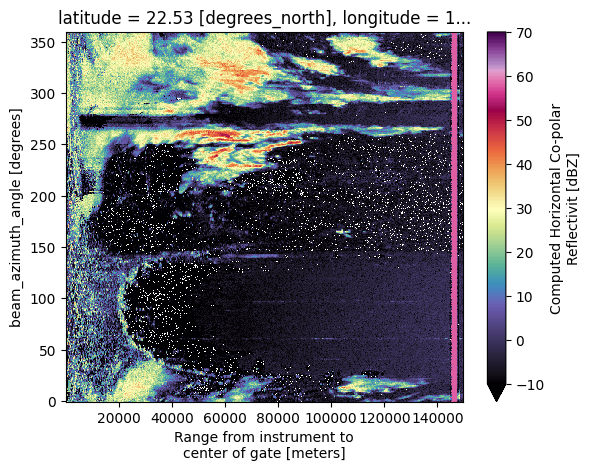

In [4]:
radar.sweep_0.DBZ.plot(cmap="ChaseSpectral", vmin=-10, vmax=70)

### Plot Time vs. Range

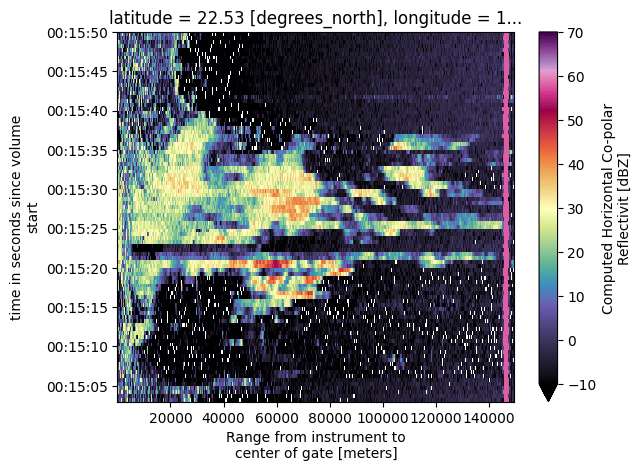

In [5]:
radar.sweep_0.DBZ.swap_dims({"azimuth": "time"}).sortby("time").plot(
    cmap="ChaseSpectral", vmin=-10, vmax=70
)

### Georeference

In [6]:
radar = radar.xradar.georeference()
display(radar)

<xarray.DataTree>
Group: /
│   Dimensions:              (sweep: 9)
│   Dimensions without coordinates: sweep
│   Data variables:
│       volume_number        int32 4B ...
│       platform_type        |S32 32B ...
│       primary_axis         |S32 32B ...
│       status_str           |S1 1B ...
│       instrument_type      |S32 32B ...
│       time_coverage_start  |S32 32B ...
│       time_coverage_end    |S32 32B ...
│       latitude             float64 8B ...
│       longitude            float64 8B ...
│       altitude             float64 8B ...
│       sweep_group_name     (sweep) <U7 252B 'sweep_0' 'sweep_1' ... 'sweep_8'
│       sweep_fixed_angle    (sweep) float32 36B ...
│   Attributes: (12/13)
│       Conventions:         CF/Radial instrument_parameters radar_parameters rad...
│       version:             1.2
│       title:               TIMREX
│       institution:         
│       references:          
│       source:              
│       ...                  ...
│       comment:             
│       instrument_name:     SPOLRVP8
│       site_name:           
│       scan_name:           
│       scan_id:             0
│       platform_is_mobile:  false
├── Group: /sweep_0
│       Dimensions:                    (azimuth: 483, range: 996)
│       Coordinates:
│         * azimuth                    (azimuth) float32 2kB 0.0 0.75 ... 358.5 359.2
│           elevation                  (azimuth) float32 2kB 0.5164 0.5219 ... 0.5219
│           time                       (azimuth) datetime64[ns] 4kB 2008-06-04T00:15:...
│         * range                      (range) float32 4kB 150.0 300.0 ... 1.494e+05
│           latitude                   float64 8B 22.53
│           longitude                  float64 8B 120.4
│           altitude                   float64 8B 45.0
│           crs_wkt                    int64 8B 0
│           x                          (azimuth, range) float64 4MB 0.0 ... -1.955e+03
│           y                          (azimuth, range) float64 4MB 150.0 ... 1.493e+05
│           z                          (azimuth, range) float64 4MB 46.35 ... 2.718e+03
│       Data variables: (12/18)
│           sweep_number               int32 4B ...
│           sweep_mode                 <U20 80B 'azimuth_surveillance'
│           prt_mode                   |S32 32B ...
│           follow_mode                |S32 32B ...
│           sweep_fixed_angle          float32 4B ...
│           pulse_width                (azimuth) float32 2kB ...
│           ...                         ...
│           r_calib_index              (azimuth) int8 483B ...
│           measured_transmit_power_h  (azimuth) float32 2kB ...
│           measured_transmit_power_v  (azimuth) float32 2kB ...
│           scan_rate                  (azimuth) float32 2kB ...
│           DBZ                        (azimuth, range) float32 2MB ...
│           VR                         (azimuth, range) float32 2MB ...
├── Group: /sweep_1
│       Dimensions:                    (azimuth: 483, range: 996)
│       Coordinates:
│         * azimuth                    (azimuth) float32 2kB 0.0 0.75 ... 358.5 359.2
│           elevation                  (azimuth) float32 2kB 1.104 1.104 ... 1.104 1.104
│           time                       (azimuth) datetime64[ns] 4kB 2008-06-04T00:16:...
│         * range                      (range) float32 4kB 150.0 300.0 ... 1.494e+05
│           latitude                   float64 8B 22.53
│           longitude                  float64 8B 120.4
│           altitude                   float64 8B 45.0
│           crs_wkt                    int64 8B 0
│           x                          (azimuth, range) float64 4MB 0.0 ... -1.954e+03
│           y                          (azimuth, range) float64 4MB 150.0 ... 1.493e+05
│           z                          (azimuth, range) float64 4MB 47.89 ... 4.236e+03
│       Data variables: (12/18)
│           sweep_number               int32 4B ...
│           sweep_mode                 <U2

### Plot PPI

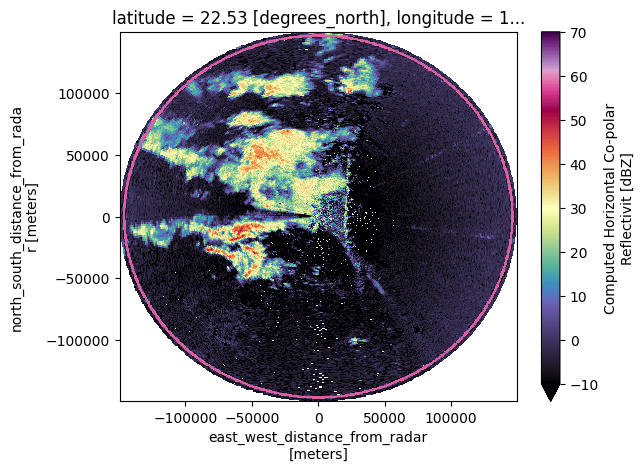

In [7]:
radar["sweep_0"]["DBZ"].plot(x="x", y="y", cmap="ChaseSpectral", vmin=-10, vmax=70)

### Filter

Apply basic reflectivity filter. This is just a demonstration.

In [8]:
def ref_filter(dtree, sweep="sweep_0", field="DBZ"):
    ds = dtree[sweep].ds
    ds = ds.where((ds[field] >= -10) & (ds[field] <= 70))
    red_patch = ds.where(
        (
            (ds[field] >= ds[field].max().values - 0.5)
            & (ds[field] <= ds[field].max().values + 0.5)
        ),
        drop=True,
    )
    rmin, rmax = int(red_patch.range.min().values - 150), int(
        red_patch.range.max().values + 150
    )
    out_of_range_mask = (ds.range < rmin) | (ds.range > rmax)
    ds[field] = ds[field].where(out_of_range_mask)
    # Interpolate missing values using the slinear method along the 'range' dimension
    ds[field] = ds[field].interpolate_na(dim="range", method="slinear")
    dtree[sweep][f"corr_{field}"] = ds[field].copy()
    return dtree[sweep]

In [9]:
swp0 = ref_filter(radar, sweep="sweep_0", field="DBZ")

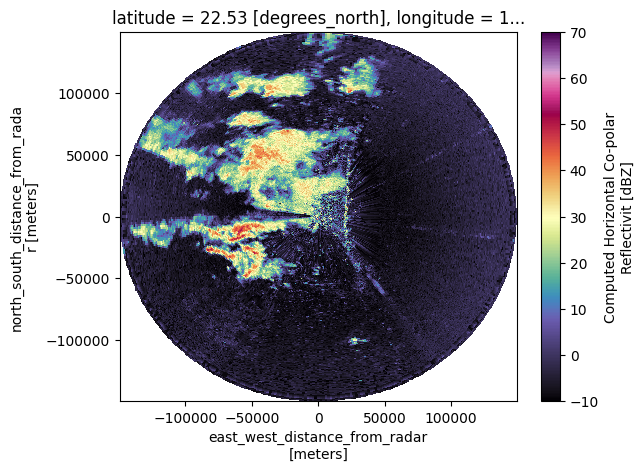

In [10]:
swp0.corr_DBZ.plot(x="x", y="y", cmap="ChaseSpectral", vmin=-10, vmax=70)

### Filter full volume

In [11]:
# Initialize an empty DataTree
result_tree = xr.DataTree()

for sweep in radar.sweep_group_name.values:
    corrected_data = ref_filter(radar, sweep, field="DBZ")

    # Convert the xarray Dataset to a DataTree and add it to the result_tree
    data_tree = xr.DataTree.from_dict(corrected_data.to_dict())

    # Copy the contents of data_tree into result_tree
    for key, value in data_tree.items():
        result_tree[key] = value

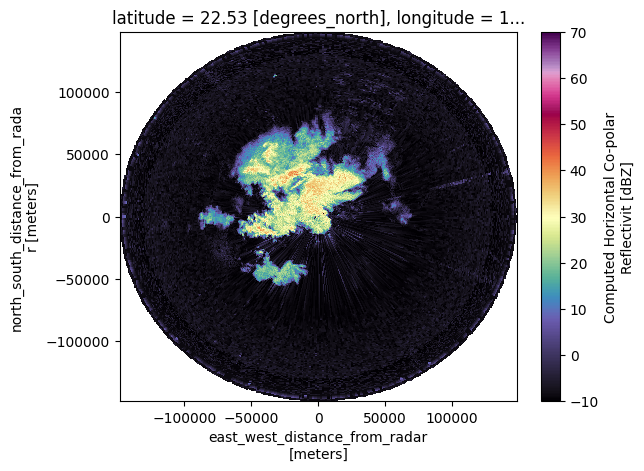

In [12]:
radar.sweep_6.corr_DBZ.plot(x="x", y="y", cmap="ChaseSpectral", vmin=-10, vmax=70)

### Export

Export to CfRadial1

In [13]:
xd.io.to_cfradial1(dtree=radar, filename="cfradial1_qced.nc", calibs=True)

In [14]:
?xd.io.to_cfradial1

### Note 

If `filename` is `None` in the `xd.io.to_cfradial1` function, it will automatically generate a<br>
filename using the instrument name and the first available timestamp from the data.
